> Projeto Desenvolve <br>
Programação Intermediária com Python <br>
Profa. Camila Laranjeira (mila@projetodesenvolve.com.br) <br>

# 4.2 - APIs


## Exercícios 🔭🌌🪐

Vamos acessar as APIs da NASA para ver algumas imagens interessantes capturadas universo afora!

#### Q1.
Crie uma chave no site oficial:
* https://api.nasa.gov

Vamos armazenar a chave de forma segura! <br>
Salve a sua chave em um arquivo `key.json` na forma:
`API_KEY=SUA_CHAVE`

Adicione o nome do arquivo `key.json` ao `.gitignore` do repositório que você fará upload da atividade.
Para isso basta abrir o arquivo `.gitignore` na pasta raíz do repositório (ou criar um caso ele não exista). Dentro do arquivo, apenas adiciona o nome do arquivo que deseja ignorar.

In [ ]:
 # chave : "34dKlM2ToGsOGeCRCu56YyfHb4rYetgYKyKBrUrP"

#### Q2. 🛰 Astronomy Picture of the Day (APOD) 🌌
> Antes de fazer os exercícios, devo te lembrar que existem limites de acesso às APIs, descritas na página principal, portanto pega leve na tentativa e erro na hora de testar seu código.

<img width=500 src=https://apod.nasa.gov/apod/image/2407/M24-HaLRGB-RC51_1024.jpg>

A primeira API que acessaremos é a mais popular de todas: astronomy picture of the day (foto astronômica do dia).

Faça uma requisição GET para a URL da API que retorna a imagem do dia! Essa é fácil já que são os valores padrão da rota principal:
* URL base: `'https://api.nasa.gov/planetary/apod'`
* Endpoint: não precisa preencher, acessaremos a raíz da API.
* Query params: preencha `api_key` com a sua chave de autenticação. Se animar mexer em outros parâmetros veja [a documentação](https://api.nasa.gov).

Ao receber a resposta (um json), você deve:
* Imprimir os campos `copyright` e `explanation`
* Com as biblioteca scikit-images e matplotlib, apresente a imagem a partir do campo `url` ou `hdurl`, e preencha o título do plot com o campo `title` do json. Uma dica de código a seguir.
```python
from skimage import io
img = io.imread(url)
## plot a matriz img com matplotlib (imshow)
```   

Copyright:
Monica Mesa
 Text: 
Cecilia Chirenti 
(NASA
GSFC, 
UMCP, 
CRESST II)

Explanation:
Have you ever seen another galaxy with your own eyes?   The featured image shows the Large Magellanic Cloud (LMC), one of the closest neighbors of our Milky Way.     If you are anywhere south of latitude 20° N (but the further south, the better), you can see it with the unaided eye if you go to a dark sky location, away from big cities and light polution.   It is a dwarf irregular galaxy about 163,000 light-years away, and a member of our Local Group of galaxies.   Despite being small, with a total mass approximately equivalent to 10% - 20% of the mass of the Milky Way, the LMC is very actively forming stars.   This is likely due in part to the gravitational push and pull of tides caused by the Milky Way on the LMC.   Some astronomers have predicted that it will collide with the Milky Way in in about 2 billion years.


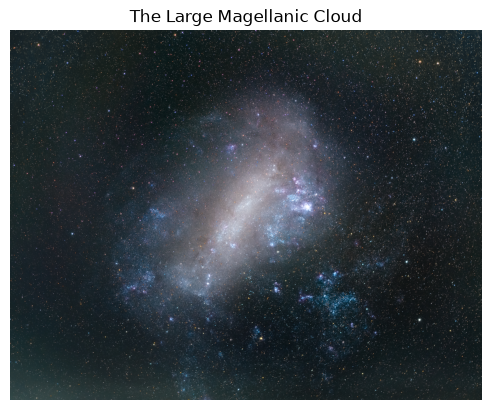

In [3]:
import json
import requests
from skimage import io
import matplotlib.pyplot as plt

# Ler chave
with open("key.json", "r") as arquivo:
    dados = json.load(arquivo)

api_key = dados["API_KEY"]

# Endpoint APOD
url = "https://api.nasa.gov/planetary/apod"

# Requisição GET
response = requests.get(url, params={"api_key": api_key})

# Converter resposta para JSON
apod = response.json()

# Imprimir campos solicitados
print("Copyright:")
print(apod.get("copyright", "Não informado"))

print("\nExplanation:")
print(apod.get("explanation", "Não informado"))

# Obter URL da imagem
img_url = apod.get("hdurl", apod.get("url"))

# Carregar imagem
img = io.imread(img_url)

# Exibir imagem
plt.imshow(img)
plt.axis("off")
plt.title(apod["title"])
plt.show()

#### Q3. Limites
A partir da resposta da query anterios, imprima o header da resposta e consulte os atributos:
* X-RateLimit-Limit: o limite total de requisições da sua chave de API
* X-RateLimit-Remaining: o limite restante de requisições da sua chave de API

In [26]:
import requests
import json

with open("key.json", "r") as arquivo:
    dados = json.load(arquivo)

api_key = dados["API_KEY"]

url = "https://api.nasa.gov/planetary/apod"

response = requests.get(
    url,
    params={"api_key": api_key}
)

# Exibir todos os headers
print(response.headers)

# Exibir os limites da API
print("\nLimite total:")
print(response.headers.get("X-RateLimit-Limit"))

print("\nRequisições restantes:")
print(response.headers.get("X-RateLimit-Remaining"))

{'Date': 'Thu, 23 Jul 2026 19:05:48 GMT', 'Content-Type': 'application/json', 'Transfer-Encoding': 'chunked', 'Connection': 'keep-alive', 'Access-Control-Allow-Origin': '*', 'Access-Control-Expose-Headers': 'X-RateLimit-Limit, X-RateLimit-Remaining', 'Age': '2', 'Content-Encoding': 'gzip', 'Referrer-Policy': 'strict-origin-when-cross-origin', 'Strict-Transport-Security': 'max-age=31536000; includeSubDomains; preload', 'Vary': 'Accept-Encoding', 'Via': 'https/1.1 api-umbrella (ApacheTrafficServer [cMsSf ])', 'X-Api-Umbrella-Request-Id': 'cvi1f9tfibjejso2nja0', 'X-Cache': 'MISS', 'X-Content-Type-Options': 'nosniff', 'X-Powered-By': 'appdat', 'X-Ratelimit-Limit': '4000', 'X-Ratelimit-Remaining': '3984', 'X-Using-Nginx-Controller': 'true', 'X-Vcap-Request-Id': '2834d2e9-e9b8-4499-5b1e-c36ec03b74b3', 'X-Xss-Protection': '1; mode=block', 'X-Frame-Options': 'SAMEORIGIN'}

Limite total:
4000

Requisições restantes:
3984


### Q4. Mars Rover Photos 🚀🚙 📷

<img width=500 src=https://www.nasa.gov/wp-content/uploads/2019/10/pia23378-16.jpg>

Essa API retorna dados (incluindo imagens capturadas) sobre os veículos que hoje habitam o planeta Marte. São os rovers `opportunity`, `spirit` e o mais famoso, o `curiosity` (da foto acima).

Antes de requisitar imagens, vamos ver o relatório de dados coletados por um deles, o `curiosity`. Isso vai nos ajudar a montar a query de imagens coletadas.

Faça uma requisição GET para a seguinte URL:
* URL base: `'https://api.nasa.gov/mars-photos/api/v1'`
* endpoint: `'/manifests/{nome_do_rover}'`
* query parameters: preencha `api_key` com a sua chave de autenticação.

Extraia o json da resposta retornada. O campo principal é o `'photo_manifest'`, do qual queremos acessar os seguintes valores:
* `max_sol`: Máximo "dia marciano" de coleta de fotos. O dia marciano tem 24 horas, 39 minutos e 35 segundos.
* `max_date`: Última data terrestre de coleta de fotos, na forma `'aaaa-mm-dd'`.

Imprima esses dois atributos da resposta e os use no próximo exercício para coletar as fotos mais recentes tiradas. 

In [ ]:
import json
import requests

# Ler a chave da API
with open("key.json", "r") as arquivo:
    dados = json.load(arquivo)

api_key = dados["API_KEY"]

# URL do manifesto do rover Curiosity
url = "https://api.nasa.gov/mars-photos/api/v1/manifests/curiosity"

response = requests.get(
    url,
    params={
        "api_key": api_key
    }
)

print("Status:", response.status_code)

if response.status_code == 200:

    dados = response.json()

    manifest = dados["photo_manifest"]

    max_sol = manifest["max_sol"]
    max_date = manifest["max_date"]

    print("Max Sol:", max_sol)
    print("Max Date:", max_date)

else:
    print("Erro:")
    print(response.text)





404
https://api.nasa.gov/mars-photos/api/v1/manifests/curiosity?api_key=DEMO_KEY


#### Q5.

Faça uma requisição GET para a URL da API que retorna links para as imagens coletadas pelos rovers.

* URL base: `'https://api.nasa.gov/mars-photos/api/v1'`
* Endpoint: `/rovers/{nome_do_rover}/photos`
* Query params sugeridos: 
    * `api_key`: sua chave de autenticação.
    * `sol`: dia marciano que deseja coletar (de 0 a `max_sol` coletado anteriormente)
    * `page`: você pode paginar entre as respostas! São retornados 25 resultados por página.

A resposta esperada estará no formato a seguir, uma lista no campo `'photos'` onde cada item é um dicionário com os dados da foto tirada. Dentre os dados há o campo `camera` indicando qual das câmeras do rover tirou a foto. As fotos mais interessantes (na minha opinião, claro) são das câmeras de navegação (`"name": "NAVCAM"`) e as de prevenção de colisão (frente: `"name": "FHAZ"` e trás `"name": "RHAZ"`) onde dá pra ver partes do robô!

**Seu trabalho é**:
* Paginar a requisição acima até que a resposta seja `None`
* Escolher uma ou mais câmeras (ex: `NAVCAM`, `FHAZ`, `RHAZ`), e em um laço de repetição plotar todas as imagens retornadas daquela câmera. Use novamente as bibliotecas scikit-image e matplotlib. 
  * O título da imagem deve ter a página da requisição, nome da câmera e id da imagem.

```json
{
  "photos": [
    {
      "id": 1228212,
      "sol": 4102,
      "camera": {
        "id": 20,
        "name": "FHAZ",
        "rover_id": 5,
        "full_name": "Front Hazard Avoidance Camera"
      },
      "img_src": "https://mars.nasa.gov/msl-raw-images/proj/msl/redops/ods/surface/sol/04102/opgs/edr/fcam/FLB_761645828EDR_F1060660FHAZ00302M_.JPG",
      "earth_date": "2024-02-19",
      "rover": {
        "id": 5,
        "name": "Curiosity",
        ...
      }
    }
    {
      "id": 1228213,
      "sol": 4102, 
      ...
    }
```



In [ ]:
import json
import requests
import matplotlib.pyplot as plt
from skimage import io

# Ler chave da API
with open("key.json", "r") as arquivo:
    dados = json.load(arquivo)

api_key = dados["API_KEY"]

# Valor obtido na questão 4
max_sol = 4102

cameras_desejadas = ["NAVCAM", "FHAZ", "RHAZ"]

page = 1

while True:

    response = requests.get(
        "https://api.nasa.gov/mars-photos/api/v1/rovers/curiosity/photos",
        params={
            "api_key": api_key,
            "sol": max_sol,
            "page": page
        }
    )

    if response.status_code != 200:
        print("Erro:", response.status_code)
        print(response.text)
        break

    dados = response.json()

    fotos = dados["photos"]

    if len(fotos) == 0:
        print("Fim da paginação.")
        break

    print(f"Página {page}: {len(fotos)} fotos encontradas.")

    for foto in fotos:

        camera = foto["camera"]["name"]

        if camera in cameras_desejadas:

            try:
                imagem = io.imread(foto["img_src"])

                plt.figure(figsize=(8, 6))
                plt.imshow(imagem)
                plt.axis("off")

                plt.title(
                    f"Página {page} | "
                    f"Câmera: {camera} | "
                    f"ID: {foto['id']}"
                )

                plt.show()

            except Exception as erro:
                print("Erro ao carregar imagem:", erro)

    page += 1
         

STATUS: 404
URL FINAL:
https://api.nasa.gov/mars-photos/api/v1/rovers/curiosity/photos?api_key=34dKlM2ToGsOGeCRCu56YyfHb4rYetgYKyKBrUrP&sol=1000&page=1
